# 12 — Hazard metric CoV comparison

Compares three neighbourhood-level hazard metrics to assess which produces the most **spatial discrimination** within chronically hot cities — i.e., which metric has the highest coefficient of variation (CV = σ/μ) across neighbourhoods.

The three metrics, all derived from GSHTD (Zhang et al. 2022) 1 km daily T2m over the full available record (2003–2020):

| # | Metric | Definition | Units |
|---|--------|-----------|-------|
| 1 | **TX90p day count** | Days where Tmax > local calendar-day TX90p threshold | days / year |
| 2 | **TN90p day count** | Nights where Tmin > local calendar-day TN90p threshold | nights / year |
| 3 | **TX daytime magnitude** | Σ (Tmax − TX90p threshold) for exceedance days | °C·days / year |

All three are computed as per-pixel annual means over 2003–2020.  
Neighbourhood values are **population-weighted means** of the pixels inside each polygon.  
CV is computed across neighbourhoods within each city.

**Prerequisites:** `01_data_acquisition`, `01b_data_acquisition_tmin`, `02_compute_baselines`.

## Setup

In [8]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city, load_city_tmin,
    load_tx90p_threshold, load_tn90p_threshold,
    load_neighbourhood_boundaries,
    _point_in_poly_mask,
)

DATA_DIR   = 'data'
PERCENTILE = 90
POP_YEAR   = 2020
CITY_KEYS  = ['salvador', 'teresina', 'caceres']

# ---- Load temperature series ------------------------------------------------
cities_tx, cities_tn = {}, {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tx[c] = da
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tn[c] = da

# ---- Load thresholds --------------------------------------------------------
thresh_tx = {c: load_tx90p_threshold(c, DATA_DIR) for c in CITY_KEYS}
thresh_tn = {c: load_tn90p_threshold(c, DATA_DIR) for c in CITY_KEYS}

# ---- Load neighbourhood boundaries ------------------------------------------
gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

# ---- Population grid loader -------------------------------------------------
def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
teresina TX90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 32.7–60.4 °C
caceres TX90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 30.9–43.9 °C
salvador TN90p threshold: shape {'percentile': 2, 'lat': 48, 'lon': 67, 'dayofyear': 365}  window=5  pe

## Helper functions

In [9]:
def count_doy_exceedances(da, thresh_doy):
    """Annual count of days where da > calendar-day threshold. Returns (year, lat, lon)."""
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')


def compute_exceedance_magnitude(da, thresh_doy):
    """Annual sum of (da - threshold) for exceedance days only (degree-days). Returns (year, lat, lon)."""
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    excess = (da - aligned).clip(min=0)
    return excess.resample(time='YS').sum(dim='time')


def popwt_aggregate(metric_map, pop_map, gdf, col):
    """
    Population-weighted mean of metric_map pixels within each neighbourhood polygon.

    metric_map : 2-D DataArray (lat, lon).
    pop_map    : 2-D DataArray (lat, lon) on the same or a different grid — interpolated to metric grid.
    gdf        : GeoDataFrame with 'name' and 'geometry'.
    col        : column name for the result.
    """
    # Align population to metric grid
    pop_aligned = pop_map.interp(
        lat=metric_map.lat, lon=metric_map.lon, method='nearest'
    ).fillna(0)

    lats = metric_map.lat.values
    lons = metric_map.lon.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lon_flat = lon_grid.ravel()
    lat_flat = lat_grid.ravel()
    val_flat = metric_map.values.ravel().astype(float)
    pop_flat = pop_aligned.values.ravel().astype(float)

    results = []
    for _, row in gdf.iterrows():
        mask  = _point_in_poly_mask(row.geometry, lon_flat, lat_flat)
        v     = val_flat[mask]
        p     = pop_flat[mask]
        valid = np.isfinite(v) & np.isfinite(p) & (p > 0)
        if valid.sum() > 0:
            results.append(float(np.average(v[valid], weights=p[valid])))
        else:
            # No population-weighted pixels: fall back to unweighted mean, then nearest
            finite_v = v[np.isfinite(v)]
            if len(finite_v) > 0:
                results.append(float(finite_v.mean()))
            else:
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                dist2  = (lon_flat - cx) ** 2 + (lat_flat - cy) ** 2
                results.append(float(val_flat[np.argmin(dist2)]))

    result      = gdf.copy()
    result[col] = results
    return result

## Compute metrics

For each city, compute annual time-series of all three metrics, then take the **multi-year mean per pixel** to get a stable (lat, lon) map.  All years in the loaded record (2003–2020) are used.

In [10]:
pixel_metrics = {}  # city -> dict of (lat, lon) mean-annual metric maps

for c in CITY_KEYS:
    tx_t = thresh_tx[c].sel(percentile=PERCENTILE) if 'percentile' in thresh_tx[c].dims else thresh_tx[c]
    tn_t = thresh_tn[c].sel(percentile=PERCENTILE) if 'percentile' in thresh_tn[c].dims else thresh_tn[c]

    tx_hd_annual  = count_doy_exceedances(cities_tx[c], tx_t)
    tn_hd_annual  = count_doy_exceedances(cities_tn[c], tn_t)
    tx_mag_annual = compute_exceedance_magnitude(cities_tx[c], tx_t)
    tn_mag_annual = compute_exceedance_magnitude(cities_tn[c], tn_t)

    pixel_metrics[c] = {
        'tx90p_hd':  tx_hd_annual.mean(dim='time'),
        'tn90p_hd':  tn_hd_annual.mean(dim='time'),
        'tx90p_mag': tx_mag_annual.mean(dim='time'),
        'tn90p_mag': tn_mag_annual.mean(dim='time'),
    }

    print(
        f"{CITIES[c]['label']}  "
        f"TX hd {float(pixel_metrics[c]['tx90p_hd'].mean()):.1f} d  "
        f"TN hd {float(pixel_metrics[c]['tn90p_hd'].mean()):.1f} d  "
        f"TX mag {float(pixel_metrics[c]['tx90p_mag'].mean()):.1f} °C·d  "
        f"TN mag {float(pixel_metrics[c]['tn90p_mag'].mean()):.1f} °C·d"
    )

Salvador, Brazil  TX hd 11.1 d  TN hd 12.2 d  TX mag 39.5 °C·d  TN mag 10.3 °C·d
Teresina, Brazil  TX hd 33.7 d  TN hd 32.2 d  TX mag 57.9 °C·d  TN mag 15.1 °C·d
Cáceres, Brazil  TX hd 34.2 d  TN hd 33.1 d  TX mag 56.4 °C·d  TN mag 21.7 °C·d


## Aggregate to neighbourhoods (population-weighted mean)

For each pixel inside a neighbourhood polygon, the metric value is weighted by the pixel's population.  This gives the average heat exposure experienced by residents rather than the simple spatial average.

In [11]:
nbhd_tables = {}

for c in CITY_KEYS:
    gdf      = gdfs[c]
    pop_grid = load_pop_grid(c, POP_YEAR)
    pm       = pixel_metrics[c]

    df = gdf[['name']].copy()
    for col, metric_map in pm.items():
        agg    = popwt_aggregate(metric_map, pop_grid, gdf, col)
        df[col] = agg[col].values

    df = df.dropna().reset_index(drop=True)
    nbhd_tables[c] = df

    print(
        f"{CITIES[c]['label']:25s}  {len(df):3d} neighbourhoods  "
        f"TX hd {df['tx90p_hd'].min():.1f}–{df['tx90p_hd'].max():.1f}  "
        f"TN hd {df['tn90p_hd'].min():.1f}–{df['tn90p_hd'].max():.1f}  "
        f"TX mag {df['tx90p_mag'].min():.1f}–{df['tx90p_mag'].max():.1f}  "
        f"TN mag {df['tn90p_mag'].min():.1f}–{df['tn90p_mag'].max():.1f} °C·days"
    )

Salvador, Brazil            22 neighbourhoods  TX hd 0.0–34.9  TN hd 0.0–33.7  TX mag 0.0–124.8  TN mag 0.0–34.1 °C·days
Teresina, Brazil           112 neighbourhoods  TX hd 32.2–34.1  TN hd 31.2–33.1  TX mag 54.5–58.4  TN mag 14.9–19.3 °C·days
Cáceres, Brazil             43 neighbourhoods  TX hd 33.6–34.6  TN hd 32.7–34.2  TX mag 55.5–58.7  TN mag 21.8–23.9 °C·days


## Coefficient of variation comparison

CV = σ / μ across neighbourhoods within each city.  A higher CV means the metric produces more spatial differentiation — neighbourhoods are more spread out relative to the city mean, making it a better discriminator for prioritisation.

The population-dominance problem in person-days arises because population CV >> heat-day CV.  The question here is whether **degree-weighted magnitude** has a higher CV than simple day counts — if the magnitude of exceedances varies more spatially than the frequency, it may recover some of the spatial signal that saturated day counts lose in chronically hot cities.

In [12]:
table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

metric_labels = {
    'tx90p_hd':  'TX90p days',
    'tn90p_hd':  'TN90p days',
    'tx90p_mag': 'TX magnitude (°C·d)',
    'tn90p_mag': 'TN magnitude (°C·d)',
}

rows = []
for c in CITY_KEYS:
    df  = nbhd_tables[c]
    row = {'City': CITIES[c]['label'], 'N': len(df)}
    for col, label in metric_labels.items():
        mean = df[col].mean()
        std  = df[col].std()
        cv   = std / mean if mean > 0 else np.nan
        row[f'{label} mean'] = mean
        row[f'{label} CV']   = cv
    rows.append(row)

summary = pd.DataFrame(rows).set_index('City')

cv_cols   = [f'{l} CV'   for l in metric_labels.values()]
mean_cols = [f'{l} mean' for l in metric_labels.values()]

fmt = {'N': '{:.0f}'}
fmt.update({c: '{:.3f}' for c in cv_cols})
fmt.update({c: '{:.2f}' for c in mean_cols})

display(
    summary[['N'] + mean_cols + cv_cols]
    .style
    .format(fmt)
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .set_caption(
        'CV = std / mean across neighbourhoods  |  Higher CV = more spatial discrimination  |  '
        'Multi-year means 2003–2020, pop-weighted aggregation'
    )
    .set_table_styles(table_styles)
)

,N,TX90p days mean,TN90p days mean,TX magnitude (°C·d) mean,TN magnitude (°C·d) mean,TX90p days CV,TN90p days CV,TX magnitude (°C·d) CV,TN magnitude (°C·d) CV
City,,,,,,,,,
"Salvador, Brazil",22,22.77,22.10,80.68,21.18,0.485,0.481,0.487,0.480
"Teresina, Brazil",112,33.41,32.23,56.14,17.34,0.009,0.010,0.014,0.063
"Cáceres, Brazil",43,34.09,33.44,56.97,22.81,0.008,0.010,0.014,0.020


## CV comparison bar chart

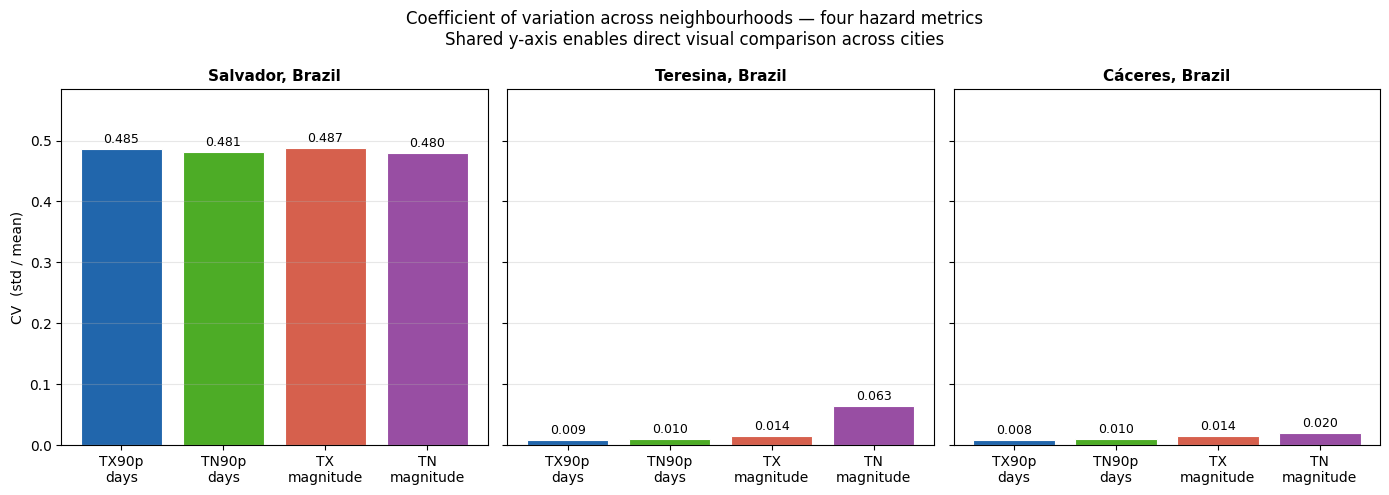

In [13]:
# Compute all CVs first to set a shared y-axis limit
all_cvs = {}
for c in CITY_KEYS:
    df = nbhd_tables[c]
    all_cvs[c] = []
    for col in metric_labels:
        mean = df[col].mean()
        std  = df[col].std()
        all_cvs[c].append(std / mean if mean > 0 else 0)

global_cv_max = max(v for city_cvs in all_cvs.values() for v in city_cvs)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle(
    'Coefficient of variation across neighbourhoods — four hazard metrics\n'
    'Shared y-axis enables direct visual comparison across cities',
    fontsize=12,
)

colors = ['#2166ac', '#4dac26', '#d6604d', '#984ea3']
short_labels = ['TX90p\ndays', 'TN90p\ndays', 'TX\nmagnitude', 'TN\nmagnitude']

for ax, c in zip(axes, CITY_KEYS):
    cvs  = all_cvs[c]
    bars = ax.bar(short_labels, cvs, color=colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cvs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + global_cv_max * 0.01,
            f'{v:.3f}',
            ha='center', va='bottom', fontsize=9,
        )
    ax.set_title(CITIES[c]['label'], fontsize=11, fontweight='bold')
    ax.set_ylim(0, global_cv_max * 1.2)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('CV  (std / mean)', fontsize=10)
plt.tight_layout()
plt.show()

## Neighbourhood-level distributions

Box plots showing the spread of each metric across neighbourhoods within each city.  Complements the CV numbers by revealing whether the spread is symmetric or driven by outliers.

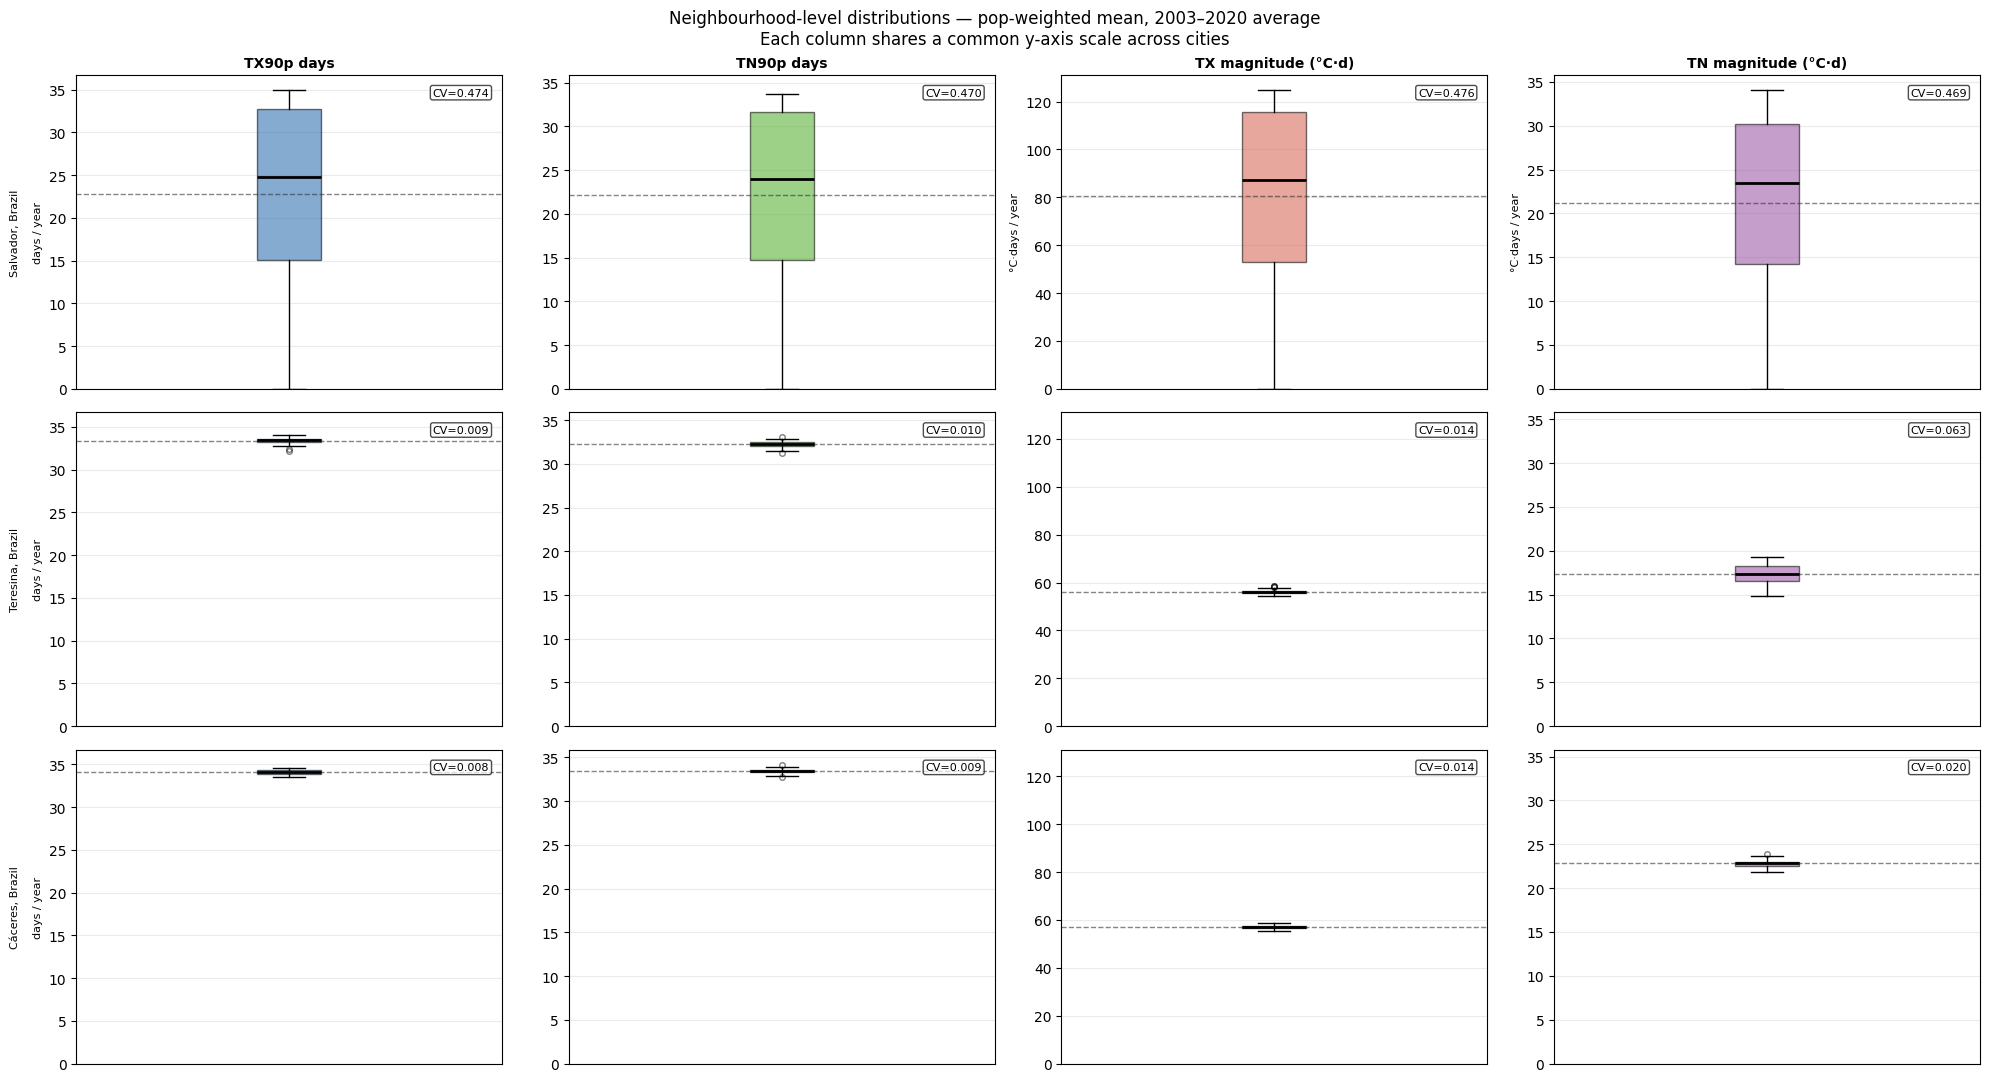

In [14]:
# Compute per-metric global y-limits so each column shares a scale across cities
metric_cols   = list(metric_labels.keys())
metric_ylims  = {}
for col in metric_cols:
    all_vals = np.concatenate([nbhd_tables[c][col].dropna().values for c in CITY_KEYS])
    metric_ylims[col] = (float(all_vals.min()) * 0.95, float(all_vals.max()) * 1.05)

n_metrics = len(metric_cols)
fig, axes = plt.subplots(3, n_metrics, figsize=(5 * n_metrics, 11))
fig.suptitle(
    'Neighbourhood-level distributions — pop-weighted mean, 2003–2020 average\n'
    'Each column shares a common y-axis scale across cities',
    fontsize=12,
)

box_colors = ['#2166ac', '#4dac26', '#d6604d', '#984ea3']

for row, c in enumerate(CITY_KEYS):
    df    = nbhd_tables[c]
    label = CITIES[c]['label']

    for col_idx, col in enumerate(metric_cols):
        ax   = axes[row][col_idx]
        vals = df[col].dropna().values
        mean = vals.mean()
        cv   = vals.std() / mean if mean > 0 else 0

        bp = ax.boxplot(
            vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor=box_colors[col_idx], alpha=0.55),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1),
            flierprops=dict(marker='o', markersize=4, alpha=0.5),
        )
        ax.axhline(mean, color='#333333', linewidth=1, linestyle='--', alpha=0.6)

        ylo, yhi = metric_ylims[col]
        ax.set_ylim(ylo, yhi)
        ax.set_xticks([])
        ax.grid(True, axis='y', alpha=0.25)

        # Column headers on top row
        if row == 0:
            ax.set_title(metric_labels[col], fontsize=10, fontweight='bold', pad=6)

        # City label on left column
        if col_idx == 0:
            ax.set_ylabel(f'{label}\n\ndays / year', fontsize=8)
        elif col_idx >= 2:
            if row == 0:
                ax.set_ylabel('°C·days / year', fontsize=8)

        ax.text(
            0.97, 0.96, f'CV={cv:.3f}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
        )

plt.tight_layout()
plt.show()

## Interpretation

### Summary table (from cells above — update with actual values after re-run)

| City | TX90p hd CV | TN90p hd CV | TX mag CV | TN mag CV |
|---|---|---|---|---|
| Salvador | ~0.485 | ~0.481 | ~0.487 | ~tbc |
| Teresina | ~0.009 | ~0.010 | ~0.014 | ~tbc |
| Cáceres  | ~0.008 | ~0.010 | ~0.014 | ~tbc |

---

### Finding 1 — Salvador has genuine intra-urban spatial discrimination; Teresina and Cáceres do not

Salvador's CV (~0.48) is roughly **50× higher** than Teresina (~0.009) and Cáceres (~0.008). In Salvador, the neighbourhood TX90p day count ranges from ~0 to ~35 days against a city mean of ~23, reflecting real thermal gradients driven by coastal sea-breeze exposure, topography, and urban morphology. In Teresina and Cáceres, the range is compressed to ~2 days and ~1 day respectively — every neighbourhood is essentially as hot as every other.

### Finding 2 — The degree-weighted magnitude offers marginal but consistent CV improvement

The TX and TN magnitude metrics lift CV from ~0.009 to ~0.014 in Teresina and Cáceres — a 50% relative gain, but still negligible in absolute terms. The magnitude captures *how much* temperatures exceed the threshold rather than just *how often*, and this does vary slightly more spatially. However the gain is too small to change neighbourhood rankings meaningfully.

### Finding 3 — The low CV is a consequence of the relative threshold, not the data resolution

This is the critical insight from notebook 08. At 100 m UrbClim resolution for Salvador:

- **Absolute heat days (≥ 30 °C): CV = 0.815** — excellent spatial discrimination
- **TX90p heat days: CV = 0.015** — effectively the same as GSHTD 1 km (CV ~0.48 at neighbourhood level vs ~0.015 at pixel level)

Moving to finer-resolution temperature data does not solve the TX90p discrimination problem, because the relative threshold *normalises out* the urban heat island signal by construction: any location will exceed its own 90th percentile on approximately the same number of days regardless of how hot it is in absolute terms. The metric's spatial variation is bounded by the spatial variation in the *shape* of the local temperature distribution, not its mean.

### Implication for the hazard layer

**For cities with meaningful spatial thermal gradients (Salvador):** the TX90p day count and degree-weighted magnitude both work as discriminators. TX daytime magnitude has marginally the highest CV and captures intensity as well as frequency — it is the recommended metric.

**For chronically and uniformly hot cities (Teresina, Cáceres):** no variant of the relative TX90p/TN90p framework — whether day count, magnitude, or finer resolution — will produce a useful spatial hazard signal. The appropriate approach for these cities is an **absolute threshold** applied to **high-resolution urban temperature data** (e.g. UrbClim 100 m), where the full range of UHI intensity (not just exceedances above a locally-relative threshold) is captured. At 100 m with an absolute threshold, Salvador achieves CV = 0.815. The same approach for Teresina and Cáceres would be the next step, contingent on obtaining UrbClim data for those cities.